In [2]:
# 1. How can you perform word tokenization using NLTK?

import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

nltk.download('punkt')
text = "Natural Language Processing with Python is fun."
word_tokens = word_tokenize(text)
print(word_tokens)


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


['Natural', 'Language', 'Processing', 'with', 'Python', 'is', 'fun', '.']


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [3]:
# 2. How can you perform sentence tokenization using NLTK?

from nltk.tokenize import sent_tokenize

text = "Hello there. How are you doing today? Natural Language Processing is interesting."
sentence_tokens = sent_tokenize(text)
print(sentence_tokens)


['Hello there.', 'How are you doing today?', 'Natural Language Processing is interesting.']


In [4]:
# 3. How can you remove stopwords from a sentence?

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
text = "This is a sample sentence demonstrating the removal of stopwords."
word_tokens = word_tokenize(text)
filtered_sentence = [word for word in word_tokens if word.lower() not in stop_words]
print(filtered_sentence)


['sample', 'sentence', 'demonstrating', 'removal', 'stopwords', '.']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [5]:
# 4. How can you perform stemming on a word?

from nltk.stem import PorterStemmer

stemmer = PorterStemmer()
words = ["running", "jumps", "easily", "fairly"]
stemmed_words = [stemmer.stem(word) for word in words]
print(stemmed_words)


['run', 'jump', 'easili', 'fairli']


In [7]:
# 5. How can you perform lemmatization on a word?

from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()
words = ["running", "jumps", "easily", "fairly"]
lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
print(lemmatized_words)


[nltk_data] Downloading package wordnet to /root/nltk_data...


['running', 'jump', 'easily', 'fairly']


In [8]:
# 6. How can you normalize a text by converting it to lowercase and removing punctuation?

import string

def normalize_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

text = "Hello, World! This is a sample text."
normalized_text = normalize_text(text)
print(normalized_text)


hello world this is a sample text


In [9]:
# 7. How can you create a co-occurrence matrix for words in a corpus?

from collections import defaultdict, Counter
import numpy as np

def create_cooccurrence_matrix(corpus, window_size=2):
    vocab = set(word for sentence in corpus for word in sentence)
    vocab = {word: i for i, word in enumerate(vocab)}
    cooccurrence_matrix = np.zeros((len(vocab), len(vocab)))

    for sentence in corpus:
        for i, word in enumerate(sentence):
            word_idx = vocab[word]
            start = max(i - window_size, 0)
            end = min(i + window_size + 1, len(sentence))
            for j in range(start, end):
                if i != j:
                    neighbor_word_idx = vocab[sentence[j]]
                    cooccurrence_matrix[word_idx][neighbor_word_idx] += 1
    return cooccurrence_matrix, vocab

corpus = [["this", "is", "a", "sample", "text"],
          ["this", "is", "another", "example", "text"]]
co_matrix, vocab = create_cooccurrence_matrix(corpus)
print(co_matrix)
print(vocab)


[[0. 1. 1. 2. 0. 1. 1.]
 [1. 0. 1. 0. 1. 0. 0.]
 [1. 1. 0. 1. 1. 0. 0.]
 [2. 0. 1. 0. 0. 0. 1.]
 [0. 1. 1. 0. 0. 1. 1.]
 [1. 0. 0. 0. 1. 0. 1.]
 [1. 0. 0. 1. 1. 1. 0.]]
{'is': 0, 'example': 1, 'another': 2, 'this': 3, 'text': 4, 'sample': 5, 'a': 6}


In [10]:
# 8. How can you apply a regular expression to extract all email addresses from a text?

import re

def extract_emails(text):
    email_pattern = r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}'
    emails = re.findall(email_pattern, text)
    return emails

text = "Please contact us at info@example.com or support@example.co.in for further information."
emails = extract_emails(text)
print(emails)


['info@example.com', 'support@example.co.in']


In [11]:
# 9. How can you perform word embedding using Word2Vec?

from gensim.models import Word2Vec

sentences = [["I", "love", "natural", "language", "processing"],
             ["Word2Vec", "is", "a", "great", "tool"]]
model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)
word_vector = model.wv['love']
print(word_vector)


[-9.5785465e-03  8.9431154e-03  4.1650687e-03  9.2347348e-03
  6.6435025e-03  2.9247368e-03  9.8040197e-03 -4.4246409e-03
 -6.8033109e-03  4.2273807e-03  3.7290000e-03 -5.6646108e-03
  9.7047603e-03 -3.5583067e-03  9.5494064e-03  8.3472609e-04
 -6.3384566e-03 -1.9771170e-03 -7.3770545e-03 -2.9795230e-03
  1.0416972e-03  9.4826873e-03  9.3558477e-03 -6.5958775e-03
  3.4751510e-03  2.2755705e-03 -2.4893521e-03 -9.2291720e-03
  1.0271263e-03 -8.1657059e-03  6.3201892e-03 -5.8000805e-03
  5.5354391e-03  9.8337233e-03 -1.6000033e-04  4.5284927e-03
 -1.8094003e-03  7.3607611e-03  3.9400971e-03 -9.0103243e-03
 -2.3985039e-03  3.6287690e-03 -9.9568366e-05 -1.2012708e-03
 -1.0554385e-03 -1.6716016e-03  6.0495257e-04  4.1650953e-03
 -4.2527914e-03 -3.8336217e-03 -5.2816868e-05  2.6935578e-04
 -1.6880632e-04 -4.7855065e-03  4.3134023e-03 -2.1719194e-03
  2.1035396e-03  6.6652300e-04  5.9696771e-03 -6.8423809e-03
 -6.8157101e-03 -4.4762576e-03  9.4358288e-03 -1.5918827e-03
 -9.4292425e-03 -5.45041

In [12]:
# 10. How can you use Doc2Vec to embed documents?

from gensim.models.doc2vec import Doc2Vec, TaggedDocument

documents = [TaggedDocument(doc, [i]) for i, doc in enumerate(sentences)]
model = Doc2Vec(documents, vector_size=100, window=5, min_count=1, workers=4)
doc_vector = model.dv[0]
print(doc_vector)


[-5.2322494e-03 -5.9804274e-03 -9.8833488e-03  8.5547389e-03
  3.5667617e-03  2.6324319e-04 -9.8828105e-03 -5.1672719e-03
 -9.7199120e-03  2.0116041e-03  2.8307009e-03  4.6442621e-03
 -4.2981193e-03 -3.1465751e-03 -3.0788584e-03 -8.7243440e-03
  2.1725444e-03  9.2278160e-03 -9.5038069e-03 -3.4585972e-03
 -3.7704292e-03  2.6080050e-03 -5.6930459e-03  2.6215329e-03
  5.8034370e-03 -8.1086205e-03 -8.3316155e-03 -9.9565731e-03
  4.9339291e-03 -9.1244634e-03  5.8435854e-03  6.8015773e-03
 -6.5079504e-03 -4.5206854e-03 -1.2554571e-03  1.6464682e-03
 -1.4816392e-03 -8.5440446e-03 -3.6037567e-03  1.7317308e-03
 -2.0570848e-03 -7.2315298e-03  4.1855122e-03 -8.5762935e-03
  2.7121757e-03 -4.6145348e-03  6.4576237e-04 -2.0574066e-03
  5.4143076e-03 -8.0045667e-03 -2.1203670e-03 -9.5385287e-05
 -6.6398564e-03 -6.5281992e-03 -1.9337829e-03  8.8053280e-03
 -1.2635464e-03  3.5369238e-03 -5.7519665e-03  8.8163204e-03
  2.9166464e-03  9.2817070e-03  4.3514241e-03 -4.2005451e-03
  2.2422590e-03 -4.41347

In [14]:
# 11. How can you perform part-of-speech tagging?

from nltk import pos_tag
from nltk.tokenize import word_tokenize
nltk.download('averaged_perceptron_tagger_eng')

text = "Natural Language Processing is fascinating."
word_tokens = word_tokenize(text)
pos_tags = pos_tag(word_tokens)
print(pos_tags)


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


[('Natural', 'JJ'), ('Language', 'NNP'), ('Processing', 'NNP'), ('is', 'VBZ'), ('fascinating', 'VBG'), ('.', '.')]


In [15]:
# 12. How can you find the similarity between two sentences using cosine similarity?

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

sentences = ["I love natural language processing",
             "I enjoy studying artificial intelligence"]
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(sentences)
similarity = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])
print(similarity)


[[0.]]


In [17]:
# 13. How can you extract named entities from a sentence?

import nltk
nltk.download('maxent_ne_chunker')
nltk.download('words')
from nltk import ne_chunk, pos_tag, word_tokenize
nltk.download('maxent_ne_chunker_tab')

text = "Barack Obama was the 44th President of the United States."
tokens = word_tokenize(text)
tags = pos_tag(tokens)
entities = ne_chunk(tags)
print(entities)


[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.


(S
  (PERSON Barack/NNP)
  (PERSON Obama/NNP)
  was/VBD
  the/DT
  44th/JJ
  President/NNP
  of/IN
  the/DT
  (GPE United/NNP States/NNPS)
  ./.)


In [18]:
# 14. How can you split a large document into smaller chunks of text?

def split_into_chunks(text, chunk_size=100):
    words = text.split()
    chunks = [' '.join(words[i:i + chunk_size]) for i in range(0, len(words), chunk_size)]
    return chunks

text = "This is a long document. " * 50
chunks = split_into_chunks(text)
print(chunks)


['This is a long document. This is a long document. This is a long document. This is a long document. This is a long document. This is a long document. This is a long document. This is a long document. This is a long document. This is a long document. This is a long document. This is a long document. This is a long document. This is a long document. This is a long document. This is a long document. This is a long document. This is a long document. This is a long document. This is a long document.', 'This is a long document. This is a long document. This is a long document. This is a long document. This is a long document. This is a long document. This is a long document. This is a long document. This is a long document. This is a long document. This is a long document. This is a long document. This is a long document. This is a long document. This is a long document. This is a long document. This is a long document. This is a long document. This is a long document. This is a long docum

In [19]:
# 15. How can you calculate the TF-IDF (Term Frequency - Inverse Document Frequency) for a set of documents?

from sklearn.feature_extraction.text import TfidfVectorizer

documents = ["I love natural language processing",
             "I enjoy studying artificial intelligence"]
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(documents)
print(tfidf_matrix.toarray())


[[0.  0.  0.  0.5 0.5 0.5 0.5 0. ]
 [0.5 0.5 0.5 0.  0.  0.  0.  0.5]]


In [20]:
# 16. How can you apply tokenization, stopword removal, and stemming in one go?

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

def preprocess_text(text):
    # Tokenization
    tokens = word_tokenize(text)

    # Stopword Removal
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word.lower() not in stop_words]

    # Stemming
    stemmer = PorterStemmer()
    tokens = [stemmer.stem(word) for word in tokens]

    return tokens

text = "Natural Language Processing with Python is fun and interesting."
preprocessed_tokens = preprocess_text(text)
print(preprocessed_tokens)


['natur', 'languag', 'process', 'python', 'fun', 'interest', '.']


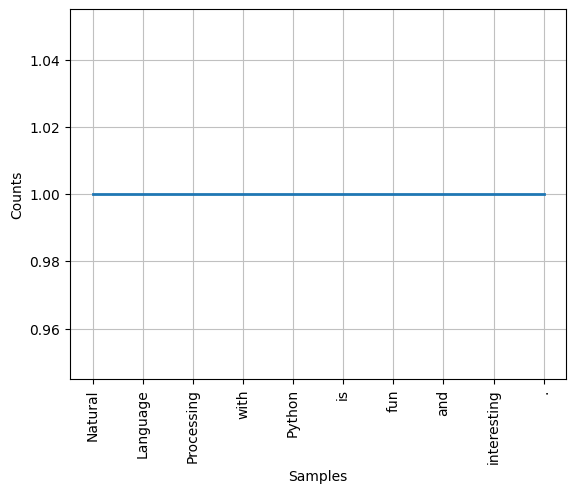

In [21]:
# 17. How can you visualize the frequency distribution of words in a sentence?

import nltk
from nltk.probability import FreqDist
import matplotlib.pyplot as plt

text = "Natural Language Processing with Python is fun and interesting."
word_tokens = word_tokenize(text)
freq_dist = FreqDist(word_tokens)

# Plot the frequency distribution
freq_dist.plot(30, cumulative=False)
plt.show()
